In [1]:
import pandas as pd

In [2]:
# Load all result files
ltsm_results   = pd.read_csv('results/lstm_results.csv')
ge_results     = pd.read_csv('results/experiment_results.csv')
hybrid_results = pd.read_csv('results/hybrid_models_results.csv')

print("GE rows     :", len(ge_results))
print("LSTM rows   :", len(ltsm_results))
print("Hybrid rows :", len(hybrid_results))
print("Hybrid methods:", sorted(hybrid_results['method'].unique()))

GE rows     : 145
LSTM rows   : 150
Hybrid rows : 600
Hybrid methods: ['ARIMA_MLP', 'ARIMA_SVR', 'SARIMA_MLP', 'SARIMA_SVR']


In [3]:
# ── Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, friedmanchisquare
import scikit_posthocs as sp
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Alias for backwards-compatibility with existing variable names
lstm_results = ltsm_results.copy()
ge_results['total_time'] = (
    ge_results['gp_runtime_seconds'] + ge_results['eval_time_seconds']
)
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Preparation and Aggregation

In [4]:
# Verify datasets are aligned across all sources
ge_datasets     = sorted(ge_results['dataset'].unique())
lstm_datasets   = sorted(lstm_results['dataset'].unique())
hybrid_datasets = sorted(hybrid_results['dataset'].unique())

print("GE datasets    :", ge_datasets)
print("LSTM datasets  :", lstm_datasets)
print("Hybrid datasets:", hybrid_datasets)
assert ge_datasets == lstm_datasets, "Dataset mismatch: GE vs LSTM"
assert ge_datasets == hybrid_datasets, "Dataset mismatch: GE vs Hybrid"
print("\nAll sources share the same 10 datasets. ✓")

print("\nRun counts per dataset:")
print("\nGE:");     print(ge_results.groupby('dataset').size().to_string())
print("\nLSTM:");   print(lstm_results.groupby('dataset').size().to_string())
print("\nHybrid (per method):"); print(hybrid_results.groupby(['dataset','method']).size().unstack())

GE datasets    : ['B1H', 'CARSALES', 'Electricity', 'GAS', 'LAKEERIE', 'Nordic', 'PIGS', 'POLLUTION', 'REDWINE', 'SUNSPOT']
LSTM datasets  : ['B1H', 'CARSALES', 'Electricity', 'GAS', 'LAKEERIE', 'Nordic', 'PIGS', 'POLLUTION', 'REDWINE', 'SUNSPOT']
Hybrid datasets: ['B1H', 'CARSALES', 'Electricity', 'GAS', 'LAKEERIE', 'Nordic', 'PIGS', 'POLLUTION', 'REDWINE', 'SUNSPOT']

All sources share the same 10 datasets. ✓

Run counts per dataset:

GE:
dataset
B1H            15
CARSALES       10
Electricity    15
GAS            15
LAKEERIE       15
Nordic         15
PIGS           15
POLLUTION      15
REDWINE        15
SUNSPOT        15

LSTM:
dataset
B1H            15
CARSALES       15
Electricity    15
GAS            15
LAKEERIE       15
Nordic         15
PIGS           15
POLLUTION      15
REDWINE        15
SUNSPOT        15

Hybrid (per method):
method       ARIMA_MLP  ARIMA_SVR  SARIMA_MLP  SARIMA_SVR
dataset                                                  
B1H                 15         15 

In [5]:
# ── Aggregate all 6 methods to mean-per-dataset ──────────────────────────────

# Genesis-HS
ge_agg = ge_results.groupby('dataset').agg(
    r2_test=('r2_test','mean'),
    rmse_test=('rmse_test','mean'),
    mse_test=('mse_test','mean'),
    total_time=('total_time','mean'),
).round(6)

# LSTM
lstm_agg = lstm_results.groupby('dataset').agg(
    r2_test=('r2_test','mean'),
    rmse_test=('rmse_test','mean'),
    mse_test=('mse_test','mean'),
    total_time=('training_time_sec','mean'),
).round(6)

# Hybrid methods (ARIMA_SVR, ARIMA_MLP, SARIMA_SVR, SARIMA_MLP)
hybrid_agg = {}
for method_key, grp in hybrid_results.groupby('method'):
    hybrid_agg[method_key] = grp.groupby('dataset').agg(
        r2_test=('r2_test','mean'),
        rmse_test=('rmse_test','mean'),
        mse_test=('mse_test','mean'),
        total_time=('training_time_sec','mean'),
    ).round(6)

# ── Unified dict keyed by display name ───────────────────────────────────────
all_agg = {
    'Genesis-HS' : ge_agg,
    'LSTM'       : lstm_agg,
    'ARIMA+SVR'  : hybrid_agg['ARIMA_SVR'],
    'ARIMA+MLP'  : hybrid_agg['ARIMA_MLP'],
    'SARIMA+SVR' : hybrid_agg['SARIMA_SVR'],
    'SARIMA+MLP' : hybrid_agg['SARIMA_MLP'],
}
METHOD_ORDER = list(all_agg.keys())
datasets     = sorted(ge_agg.index.tolist())

print("Methods  :", METHOD_ORDER)
print("Datasets :", datasets)
print("\nAggregated MSE per dataset:")
for m, agg in all_agg.items():
    vals = [f"{agg.loc[d,'mse_test']:.4f}" for d in datasets]
    print(f"  {m:12s}: {' '.join(vals)}")

Methods  : ['Genesis-HS', 'LSTM', 'ARIMA+SVR', 'ARIMA+MLP', 'SARIMA+SVR', 'SARIMA+MLP']
Datasets : ['B1H', 'CARSALES', 'Electricity', 'GAS', 'LAKEERIE', 'Nordic', 'PIGS', 'POLLUTION', 'REDWINE', 'SUNSPOT']

Aggregated MSE per dataset:
  Genesis-HS  : 0.0005 0.0785 0.0037 0.0087 0.0014 0.0004 0.0100 0.0133 0.0105 0.0253
  LSTM        : 0.0005 0.1255 0.0226 0.0191 0.0017 0.0010 0.0138 0.0366 0.0560 0.0101
  ARIMA+SVR   : 0.0019 0.0261 0.0061 0.0029 0.0020 0.0004 0.0152 0.0174 0.0275 0.0156
  ARIMA+MLP   : 0.0011 0.0204 0.0055 0.0018 0.0015 0.0004 0.0124 0.0111 0.0181 0.0160
  SARIMA+SVR  : 0.0015 0.0262 0.0061 0.0029 0.0020 0.0005 0.0147 0.0174 0.0269 0.0360
  SARIMA+MLP  : 0.0004 0.0217 0.0025 0.0019 0.0015 0.0003 0.0114 0.0111 0.0185 0.0403


In [6]:
# ── Build performance matrices (10 datasets × 6 methods) — MSE only ─────────
perf_matrix_mse  = pd.DataFrame(
    {m: agg.loc[datasets, 'mse_test']  for m, agg in all_agg.items()},
    index=datasets,
)
perf_matrix_time = pd.DataFrame(
    {m: agg.loc[datasets, 'total_time'] for m, agg in all_agg.items()},
    index=datasets,
)

print("Performance matrix — Test MSE (mean per dataset):")
print(perf_matrix_mse.round(4).to_string())

Performance matrix — Test MSE (mean per dataset):
             Genesis-HS    LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
B1H              0.0005  0.0005     0.0019     0.0011      0.0015      0.0004
CARSALES         0.0785  0.1255     0.0261     0.0204      0.0262      0.0217
Electricity      0.0037  0.0226     0.0061     0.0055      0.0061      0.0025
GAS              0.0087  0.0191     0.0029     0.0018      0.0028      0.0019
LAKEERIE         0.0014  0.0017     0.0020     0.0015      0.0020      0.0015
Nordic           0.0004  0.0010     0.0004     0.0004      0.0005      0.0003
PIGS             0.0100  0.0138     0.0152     0.0124      0.0147      0.0114
POLLUTION        0.0133  0.0366     0.0174     0.0111      0.0174      0.0111
REDWINE          0.0105  0.0560     0.0275     0.0181      0.0269      0.0185
SUNSPOT          0.0253  0.0101     0.0156     0.0160      0.0360      0.0403


## 2. Multi-Method Statistical Analysis: Friedman + Nemenyi

In [7]:
# ── Friedman omnibus test ────────────────────────────────────────────────────
# H0: all 6 methods have the same distribution of MSE scores across datasets
mse_arrays = [perf_matrix_mse[m].values for m in METHOD_ORDER]
f_stat, f_pval = friedmanchisquare(*mse_arrays)

print("FRIEDMAN TEST — Test MSE Scores")
print("=" * 60)
print(f"Chi² statistic : {f_stat:.4f}")
print(f"P-value        : {f_pval:.6f}")
print(f"Datasets  (N)  : {len(datasets)}")
print(f"Methods   (k)  : {len(METHOD_ORDER)}")
print()
if f_pval < 0.05:
    print(f"SIGNIFICANT  (p = {f_pval:.4f} < 0.05)")
    print("→ At least one method differs significantly from the others.")
    print("  Proceeding to Nemenyi post-hoc for pairwise comparisons.")
else:
    print(f"NOT SIGNIFICANT  (p = {f_pval:.4f} ≥ 0.05)")
    print("→ No statistically significant differences among methods.")

FRIEDMAN TEST — Test MSE Scores
Chi² statistic : 18.9080
P-value        : 0.001999
Datasets  (N)  : 10
Methods   (k)  : 6

SIGNIFICANT  (p = 0.0020 < 0.05)
→ At least one method differs significantly from the others.
  Proceeding to Nemenyi post-hoc for pairwise comparisons.


In [8]:
# ── Nemenyi post-hoc pairwise test ──────────────────────────────────────────
nemenyi_p = sp.posthoc_nemenyi_friedman(perf_matrix_mse.values)
nemenyi_p.index   = METHOD_ORDER
nemenyi_p.columns = METHOD_ORDER

print("NEMENYI POST-HOC — Pairwise P-Values (MSE)")
print("=" * 60)
print(nemenyi_p.round(4).to_string())
print()
print("Key comparisons (Genesis-HS vs each competitor):")
for m in [x for x in METHOD_ORDER if x != 'Genesis-HS']:
    p   = nemenyi_p.loc['Genesis-HS', m]
    sig = "✓ SIGNIFICANT" if p < 0.05 else "  not sig."
    print(f"  Genesis-HS  vs  {m:12s} : p = {p:.4f}  {sig}")

NEMENYI POST-HOC — Pairwise P-Values (MSE)
            Genesis-HS    LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
Genesis-HS      1.0000  0.1594     0.3241     0.9999      0.2610      0.9912
LSTM            0.1594  1.0000     0.9992     0.0902      0.9999      0.0335
ARIMA+SVR       0.3241  0.9992     1.0000     0.2060      1.0000      0.0902
ARIMA+MLP       0.9999  0.0902     0.2060     1.0000      0.1594      0.9992
SARIMA+SVR      0.2610  0.9999     1.0000     0.1594      1.0000      0.0660
SARIMA+MLP      0.9912  0.0335     0.0902     0.9992      0.0660      1.0000

Key comparisons (Genesis-HS vs each competitor):
  Genesis-HS  vs  LSTM         : p = 0.1594    not sig.
  Genesis-HS  vs  ARIMA+SVR    : p = 0.3241    not sig.
  Genesis-HS  vs  ARIMA+MLP    : p = 0.9999    not sig.
  Genesis-HS  vs  SARIMA+SVR   : p = 0.2610    not sig.
  Genesis-HS  vs  SARIMA+MLP   : p = 0.9912    not sig.


In [9]:
# ── Supplementary: Wilcoxon Signed-Rank (Genesis-HS vs LSTM) ────────────────
# MSE: lower is better. differences = LSTM_MSE - GE_MSE → positive when Genesis-HS better
ge_mse_scores   = perf_matrix_mse['Genesis-HS'].values
lstm_mse_scores = perf_matrix_mse['LSTM'].values
w_stat, w_pval = wilcoxon(ge_mse_scores, lstm_mse_scores, alternative='two-sided')

differences = lstm_mse_scores - ge_mse_scores  # positive when Genesis-HS has lower MSE
cohens_d    = differences.mean() / differences.std() if differences.std() != 0 else 0.0
effect      = (
    "negligible" if abs(cohens_d) < 0.2 else
    "small"      if abs(cohens_d) < 0.5 else
    "medium"     if abs(cohens_d) < 0.8 else "large"
)
ci = stats.t.interval(
    0.95, len(differences) - 1,
    loc=differences.mean(),
    scale=differences.std() / np.sqrt(len(differences)),
)

print("SUPPLEMENTARY: Wilcoxon Signed-Rank — Genesis-HS vs LSTM (MSE)")
print("=" * 60)
print(f"Statistic : {w_stat:.4f}")
print(f"P-value   : {w_pval:.6f}  ({'Significant' if w_pval < 0.05 else 'Not significant'})")
print(f"Cohen's d : {cohens_d:.4f}  ({effect} effect size)")
print(f"95% CI    : [{ci[0]:.4f}, {ci[1]:.4f}]")
if ci[0] > 0:
    print("→ Genesis-HS significantly better (lower MSE, CI excludes 0)")
elif ci[1] < 0:
    print("→ LSTM significantly better (lower MSE, CI excludes 0)")
else:
    print("→ CI includes 0; marginal evidence")

SUPPLEMENTARY: Wilcoxon Signed-Rank — Genesis-HS vs LSTM (MSE)
Statistic : 7.0000
P-value   : 0.037109  (Significant)
Cohen's d : 0.6963  (medium effect size)
95% CI    : [-0.0004, 0.0272]
→ CI includes 0; marginal evidence


## 3. Rankings (Demšar 2006 Framework)

In [10]:
# Rank methods within each dataset (rank 1 = best MSE, i.e. lowest MSE)
rank_matrix = perf_matrix_mse.rank(axis=1, ascending=True, method='average')
mean_ranks  = rank_matrix.mean().sort_values()

print("MEAN RANKS ACROSS DATASETS (MSE — lower rank = better)")
print("=" * 60)
for method, rank in mean_ranks.items():
    bar = "█" * int(rank * 4)
    print(f"  {method:15s}: {rank:.4f}  {bar}")

print("\nDetailed ranks per dataset:")
print(rank_matrix[METHOD_ORDER].round(2).to_string())

MEAN RANKS ACROSS DATASETS (MSE — lower rank = better)
  SARIMA+MLP     : 2.2000  ████████
  ARIMA+MLP      : 2.5000  ██████████
  Genesis-HS     : 2.7000  ██████████
  ARIMA+SVR      : 4.4000  █████████████████
  SARIMA+SVR     : 4.5000  ██████████████████
  LSTM           : 4.7000  ██████████████████

Detailed ranks per dataset:
             Genesis-HS  LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
B1H                 3.0   2.0        6.0        4.0         5.0         1.0
CARSALES            5.0   6.0        3.0        1.0         4.0         2.0
Electricity         2.0   6.0        4.5        3.0         4.5         1.0
GAS                 5.0   6.0        4.0        1.0         3.0         2.0
LAKEERIE            1.0   4.0        6.0        2.0         5.0         3.0
Nordic              2.0   6.0        3.0        4.0         5.0         1.0
PIGS                1.0   4.0        6.0        3.0         5.0         2.0
POLLUTION           3.0   6.0        4.5        2.0        

## 4. Performance Metrics

In [11]:
# Wide comparison table: per dataset × per method (MSE only)
rows = []
for ds in datasets:
    row = {'Dataset': ds}
    for m, agg in all_agg.items():
        row[f'{m}_MSE'] = round(agg.loc[ds, 'mse_test'], 4)
    rows.append(row)

comp_df = pd.DataFrame(rows).set_index('Dataset')
mse_cols = [f'{m}_MSE' for m in METHOD_ORDER]

print("COMPREHENSIVE PERFORMANCE TABLE (MSE)")
print(comp_df[mse_cols].rename(columns=lambda c: c.replace('_MSE', '')).to_string())

comp_df.to_csv('results/comparison_summary.csv')
print("\nSaved → results/comparison_summary.csv")

COMPREHENSIVE PERFORMANCE TABLE (MSE)
             Genesis-HS    LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
Dataset                                                                      
B1H              0.0005  0.0005     0.0019     0.0011      0.0015      0.0004
CARSALES         0.0785  0.1255     0.0261     0.0204      0.0262      0.0217
Electricity      0.0037  0.0226     0.0061     0.0055      0.0061      0.0025
GAS              0.0087  0.0191     0.0029     0.0018      0.0028      0.0019
LAKEERIE         0.0014  0.0017     0.0020     0.0015      0.0020      0.0015
Nordic           0.0004  0.0010     0.0004     0.0004      0.0005      0.0003
PIGS             0.0100  0.0138     0.0152     0.0124      0.0147      0.0114
POLLUTION        0.0133  0.0366     0.0174     0.0111      0.0174      0.0111
REDWINE          0.0105  0.0560     0.0275     0.0181      0.0269      0.0185
SUNSPOT          0.0253  0.0101     0.0156     0.0160      0.0360      0.0403

Saved → results/compariso

In [12]:
# 6×6 Pairwise win-rate matrix (MSE: row wins when row has lower MSE)
k = len(METHOD_ORDER)
win_matrix = np.zeros((k, k), dtype=int)
for ds in datasets:
    for i, mi in enumerate(METHOD_ORDER):
        for j, mj in enumerate(METHOD_ORDER):
            if i != j and perf_matrix_mse.loc[ds, mi] < perf_matrix_mse.loc[ds, mj]:
                win_matrix[i, j] += 1

win_df = pd.DataFrame(win_matrix, index=METHOD_ORDER, columns=METHOD_ORDER)

print("PAIRWISE WIN-RATE MATRIX  (cell i,j = datasets where ROW beats COL on MSE)")
print("=" * 70)
print(win_df.to_string())

PAIRWISE WIN-RATE MATRIX  (cell i,j = datasets where ROW beats COL on MSE)
            Genesis-HS  LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
Genesis-HS           0     8          7          6           8           4
LSTM                 2     0          4          2           4           1
ARIMA+SVR            3     6          0          2           3           1
ARIMA+MLP            4     8          8          0          10           5
SARIMA+SVR           2     6          5          0           0           1
SARIMA+MLP           6     9          9          5           9           0


## 5. Visualizations

Critical Difference (α=0.05, k=6, N=10): CD = 2.3845


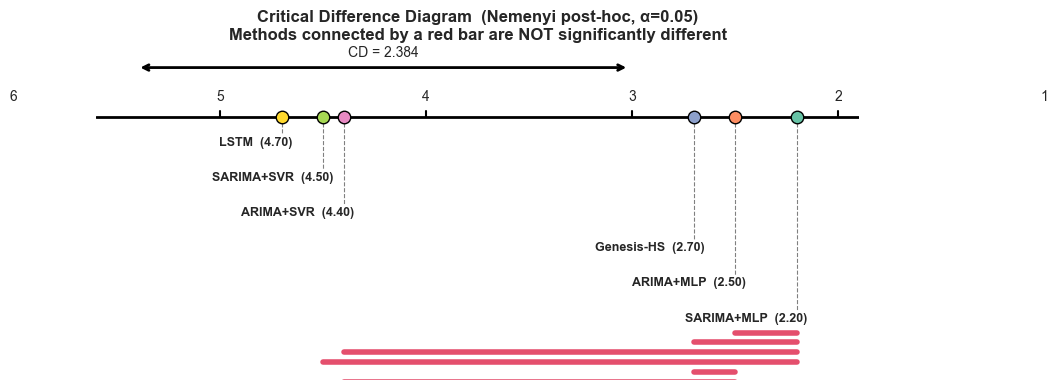

In [13]:
# ── (1) Critical Difference (CD) Diagram ────────────────────────────────────
# Standard companion to the Nemenyi test (Demšar 2006).
# Connects methods whose rank difference < CD with a thick bar → not sig. different.
#
# q_{0.05} for k=6 from Demšar 2006 Table 5: 2.850
# CD = q * sqrt(k*(k+1) / (6*N))

q_alpha    = 2.850   # Nemenyi critical value for k=6, alpha=0.05
k_methods  = len(METHOD_ORDER)
N_datasets = len(datasets)
cd_value   = q_alpha * np.sqrt(k_methods * (k_methods + 1) / (6 * N_datasets))
print(f"Critical Difference (α=0.05, k={k_methods}, N={N_datasets}): CD = {cd_value:.4f}")

sorted_ranks = mean_ranks.sort_values()
methods_s    = sorted_ranks.index.tolist()
ranks_s      = sorted_ranks.values

fig, ax = plt.subplots(figsize=(11, 4))

lo, hi = min(ranks_s) - 0.3, max(ranks_s) + 0.3
ax.set_xlim(lo, hi + 0.6)
ax.set_ylim(-1.5, len(methods_s) + 1.8)
ax.invert_xaxis()   # rank 1 (best) on the right

# Axis line
ax.plot([lo, hi + 0.6], [len(methods_s), len(methods_s)], color='black', linewidth=2)

# Tick marks & labels
for r in np.arange(1, len(METHOD_ORDER) + 1):
    ax.plot([r, r], [len(methods_s), len(methods_s) + 0.15], color='black', linewidth=1.5)
    ax.text(r, len(methods_s) + 0.35, str(r), ha='center', va='bottom', fontsize=10)

# Vertical connectors + method labels
palette_cd = sns.color_palette("Set2", n_colors=len(methods_s))
for i, (m, r) in enumerate(zip(methods_s, ranks_s)):
    y_pos = i
    ax.plot([r, r], [len(methods_s), y_pos + 0.5],
            color='gray', linewidth=0.8, linestyle='--')
    ax.plot(r, len(methods_s), 'o',
            color=palette_cd[i], markersize=9, zorder=5,
            markeredgecolor='black', markeredgewidth=1)
    ax.text(r - 0.05, y_pos + 0.25,
            f'{m}  ({r:.2f})',
            ha='right', va='center', fontsize=9, fontweight='bold')

# CD annotation (top-left)
cd_x1 = hi + 0.4
cd_x2 = cd_x1 - cd_value
ax.annotate('',
    xy=(cd_x2, len(methods_s) + 1.4),
    xytext=(cd_x1, len(methods_s) + 1.4),
    arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text((cd_x1 + cd_x2) / 2, len(methods_s) + 1.62,
        f'CD = {cd_value:.3f}',
        ha='center', va='bottom', fontsize=10)

# Non-significant groups (|rank_i - rank_j| < CD)
y_bars = []
used_y = []
for i in range(len(methods_s)):
    for j in range(i + 1, len(methods_s)):
        if abs(ranks_s[i] - ranks_s[j]) < cd_value:
            y_try = -0.15
            while y_try in used_y:
                y_try -= 0.28
            used_y.append(y_try)
            ax.plot([ranks_s[i], ranks_s[j]], [y_try, y_try],
                    color='crimson', linewidth=4, alpha=0.75, solid_capstyle='round')

ax.axis('off')
ax.set_title(
    f'Critical Difference Diagram  (Nemenyi post-hoc, α=0.05)\n'
    f'Methods connected by a red bar are NOT significantly different',
    fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

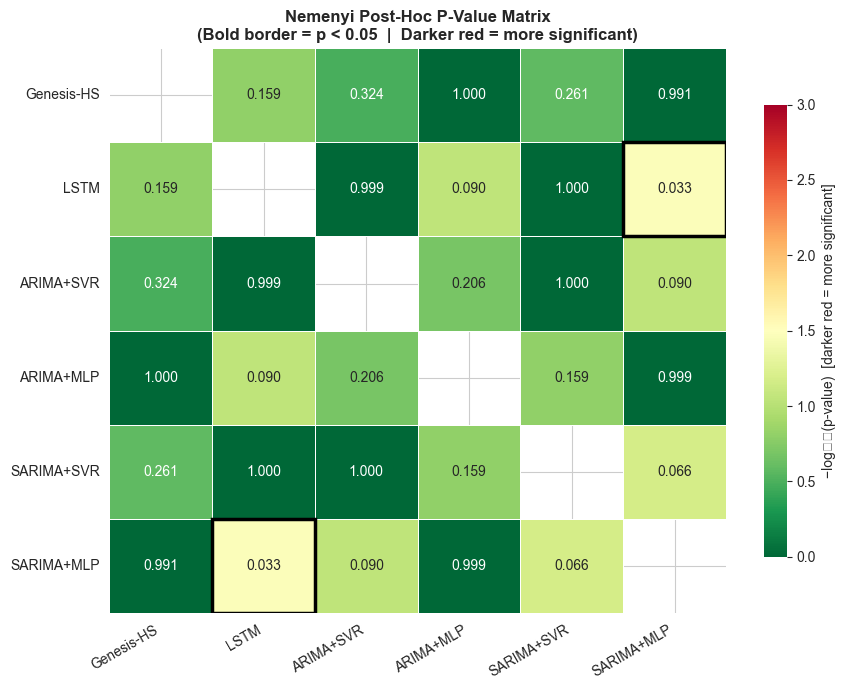

Pairs with bold border are statistically significantly different (p < 0.05)


In [14]:
# ── (2) Nemenyi P-Value Heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

mask = np.eye(len(METHOD_ORDER), dtype=bool)

# Annotate with actual p-values
annot_mat = nemenyi_p.copy().astype(str)
for i in range(len(METHOD_ORDER)):
    for j in range(len(METHOD_ORDER)):
        if i == j:
            annot_mat.iloc[i, j] = '—'
        else:
            annot_mat.iloc[i, j] = f"{nemenyi_p.iloc[i, j]:.3f}"

# Color by -log10(p) so significant cells stand out
log_p_arr = nemenyi_p.to_numpy(dtype=float).copy()
np.fill_diagonal(log_p_arr, np.nan)
log_p_clipped = np.where(np.isnan(log_p_arr), np.nan,
                         np.clip(log_p_arr, 1e-10, None))
log_p_vals = -np.log10(log_p_clipped, where=~np.isnan(log_p_clipped),
                       out=np.full_like(log_p_clipped, np.nan))
log_p_vals_df = pd.DataFrame(log_p_vals, index=METHOD_ORDER, columns=METHOD_ORDER)

sns.heatmap(
    log_p_vals_df,
    annot=annot_mat,
    fmt='',
    cmap='RdYlGn_r',
    mask=mask,
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=3,
    cbar_kws={'label': '−log₁₀(p-value)  [darker red = more significant]', 'shrink': 0.8},
)

# Bold border for significant cells (p < 0.05)
for i, m1 in enumerate(METHOD_ORDER):
    for j, m2 in enumerate(METHOD_ORDER):
        if i != j and nemenyi_p.loc[m1, m2] < 0.05:
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1, fill=False, edgecolor='black', lw=2.5))

ax.set_title(
    'Nemenyi Post-Hoc P-Value Matrix\n(Bold border = p < 0.05  |  Darker red = more significant)',
    fontsize=12, fontweight='bold')
ax.set_xticklabels(METHOD_ORDER, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(METHOD_ORDER, rotation=0,  fontsize=10)
plt.tight_layout()
plt.show()
print("Pairs with bold border are statistically significantly different (p < 0.05)")

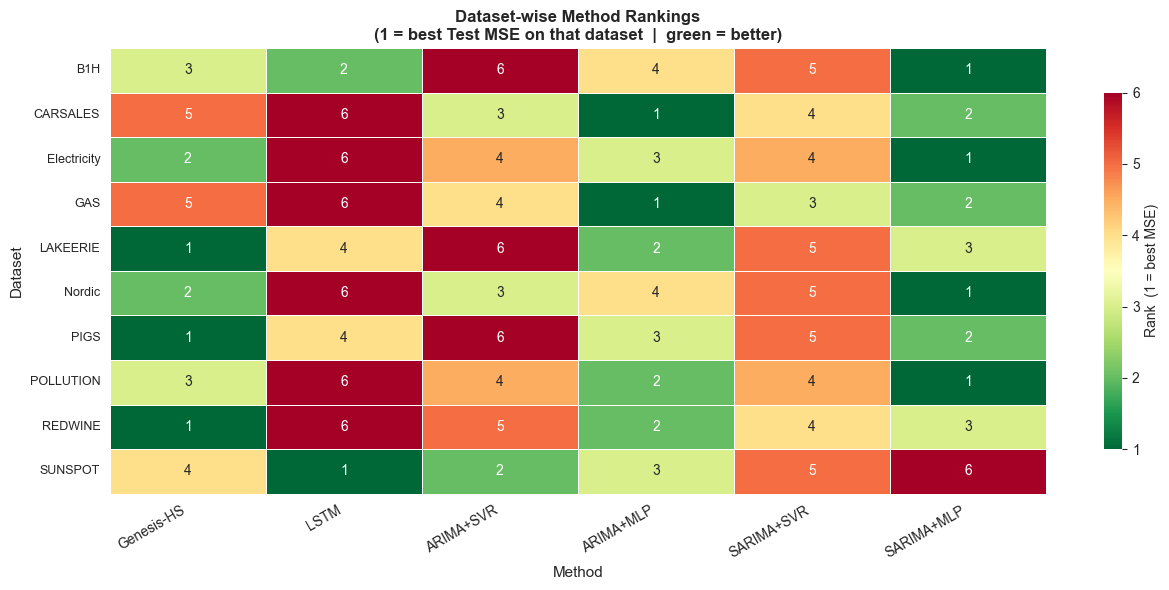

In [15]:
# ── (3) Dataset-wise Rank Heatmap ────────────────────────────────────────────
rank_display = rank_matrix[METHOD_ORDER]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    rank_display,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn_r',
    vmin=1,
    vmax=len(METHOD_ORDER),
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Rank  (1 = best MSE)', 'shrink': 0.8},
)
ax.set_title(
    'Dataset-wise Method Rankings\n(1 = best Test MSE on that dataset  |  green = better)',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Method', fontsize=11)
ax.set_ylabel('Dataset', fontsize=11)
ax.set_xticklabels(METHOD_ORDER, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(datasets, rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

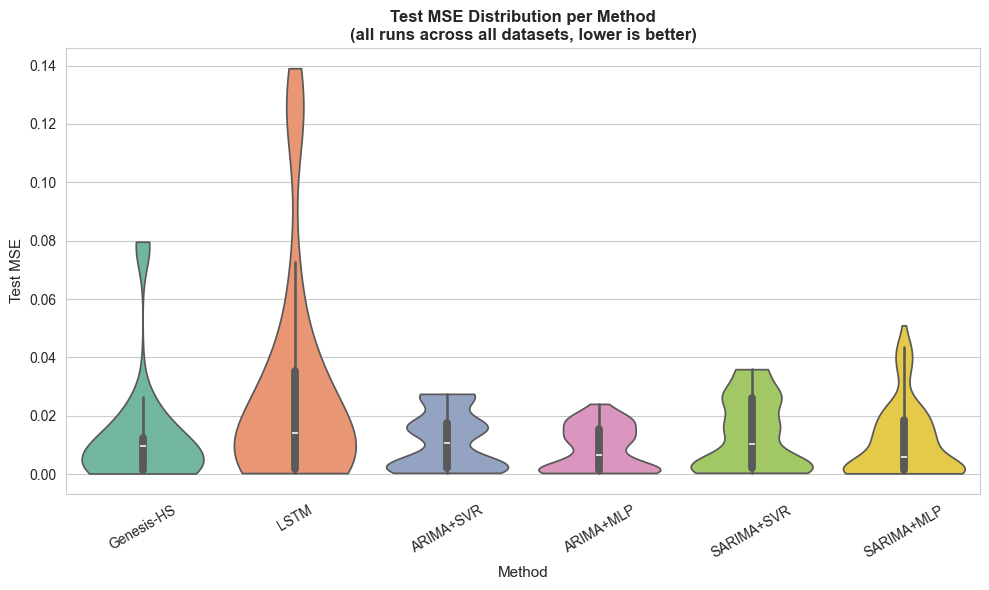

In [16]:
# ── (4) Violin Plot — Test MSE ──────────────────────────────────────────────
violin_rows = []

# Genesis-HS
for _, row in ge_results.iterrows():
    violin_rows.append({'Method': 'Genesis-HS', 'value': row['mse_test']})

# LSTM
for _, row in lstm_results.iterrows():
    violin_rows.append({'Method': 'LSTM', 'value': row['mse_test']})

# Hybrid
name_map = {'ARIMA_SVR':'ARIMA+SVR','ARIMA_MLP':'ARIMA+MLP',
            'SARIMA_SVR':'SARIMA+SVR','SARIMA_MLP':'SARIMA+MLP'}
for _, row in hybrid_results.iterrows():
    display = name_map[row['method']]
    violin_rows.append({'Method': display, 'value': row['mse_test']})

violin_df = pd.DataFrame(violin_rows)
palette   = sns.color_palette("Set2", n_colors=6)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.violinplot(data=violin_df, x='Method', y='value', order=METHOD_ORDER,
               palette=palette, ax=ax, inner='box', cut=0)
ax.set_title('Test MSE Distribution per Method\n(all runs across all datasets, lower is better)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Method', fontsize=11)
ax.set_ylabel('Test MSE', fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

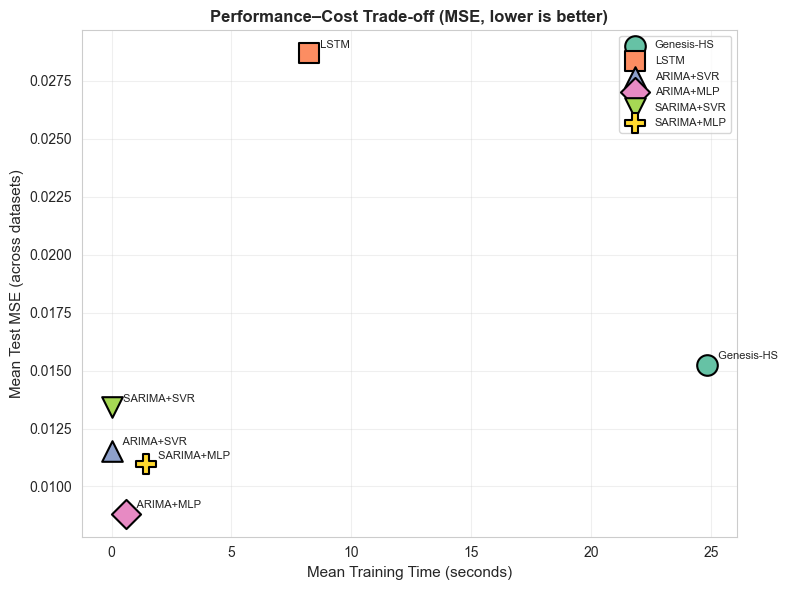

Method        | Mean Time (s) | Mean MSE
---------------------------------------------
Genesis-HS    |        24.846 |    0.0152
LSTM          |         8.241 |    0.0287
ARIMA+SVR     |         0.001 |    0.0115
ARIMA+MLP     |         0.599 |    0.0088
SARIMA+SVR    |         0.001 |    0.0134
SARIMA+MLP    |         1.452 |    0.0110


In [17]:
# ── (5) Performance–Cost Scatter (Pareto view) — MSE only ───────────────────
mean_mse  = perf_matrix_mse.mean()
mean_time = perf_matrix_time.mean()
palette   = sns.color_palette("Set2", n_colors=6)
markers   = ['o', 's', '^', 'D', 'v', 'P']

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for i, m in enumerate(METHOD_ORDER):
    ax.scatter(mean_time[m], mean_mse[m],
               s=220, color=palette[i], marker=markers[i],
               edgecolors='black', linewidths=1.5, zorder=5, label=m)
    ax.annotate(f' {m}', (mean_time[m], mean_mse[m]),
                fontsize=8, xytext=(6, 4), textcoords='offset points')
ax.set_xlabel('Mean Training Time (seconds)', fontsize=11)
ax.set_ylabel('Mean Test MSE (across datasets)', fontsize=11)
ax.set_title('Performance–Cost Trade-off (MSE, lower is better)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Method        | Mean Time (s) | Mean MSE")
print("-" * 45)
for m in METHOD_ORDER:
    print(f"{m:13s} | {mean_time[m]:13.3f} | {mean_mse[m]:9.4f}")

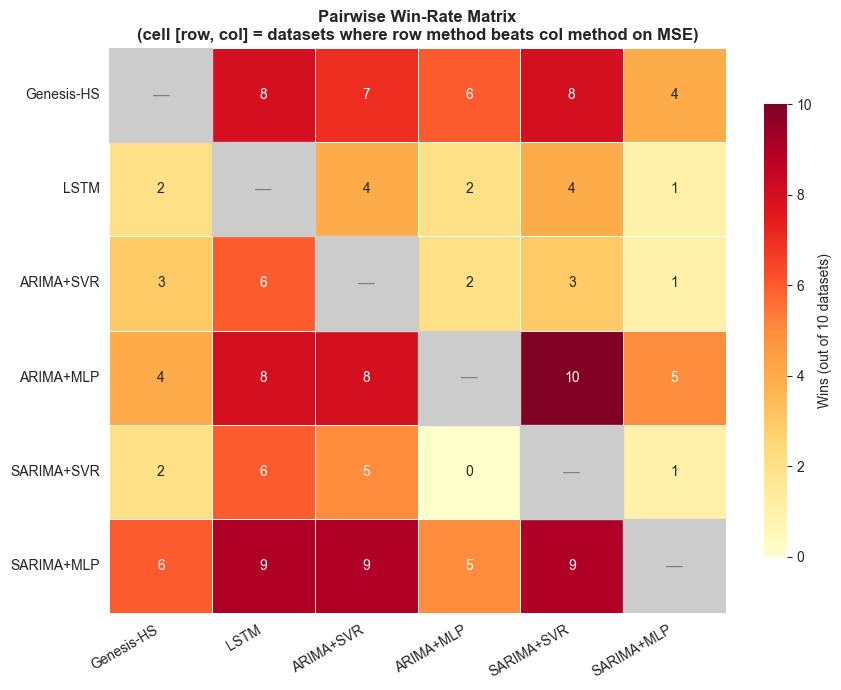

In [18]:
# ── (6) Pairwise Win-Rate Matrix Heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

diag_mask = np.eye(len(METHOD_ORDER), dtype=bool)
annot_win = win_df.astype(str)
for i in range(len(METHOD_ORDER)):
    annot_win.iloc[i, i] = '—'

sns.heatmap(
    win_df.where(~diag_mask),
    annot=annot_win,
    fmt='',
    cmap='YlOrRd',
    mask=diag_mask,
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=len(datasets),
    cbar_kws={'label': f'Wins (out of {len(datasets)} datasets)', 'shrink': 0.8},
)
# Gray diagonal
for i in range(len(METHOD_ORDER)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#cccccc'))
    ax.text(i + 0.5, i + 0.5, '—', ha='center', va='center',
            fontsize=12, color='gray')

ax.set_title(
    'Pairwise Win-Rate Matrix\n(cell [row, col] = datasets where row method beats col method on MSE)',
    fontsize=12, fontweight='bold')
ax.set_xticklabels(METHOD_ORDER, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(METHOD_ORDER, rotation=0,  fontsize=10)
plt.tight_layout()
plt.show()

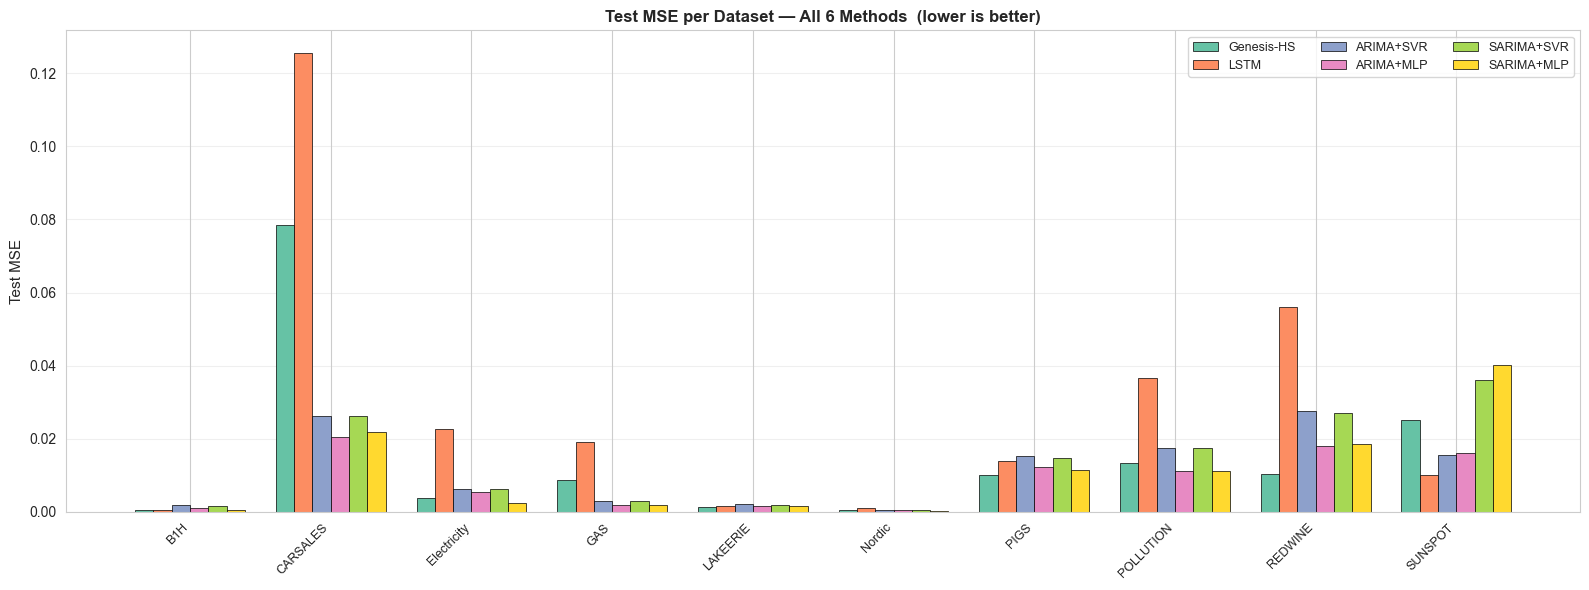

In [19]:
# ── (7) Grouped Bar Chart — MSE per Dataset ──────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
x       = np.arange(len(datasets))
width   = 0.13
palette = sns.color_palette("Set2", n_colors=6)

for i, (m, agg) in enumerate(all_agg.items()):
    vals   = [agg.loc[d, 'mse_test'] for d in datasets]
    offset = (i - (len(METHOD_ORDER) - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=m,
           color=palette[i], edgecolor='black', linewidth=0.5)

ax.set_ylabel('Test MSE', fontsize=11)
ax.set_title('Test MSE per Dataset — All 6 Methods  (lower is better)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=9, ncol=3, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

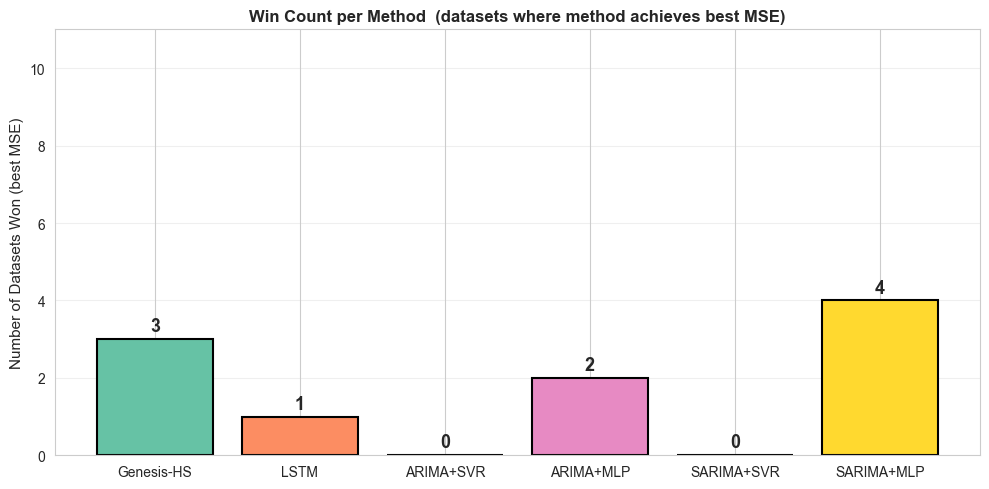

Win counts: {'Genesis-HS': 3, 'LSTM': 1, 'ARIMA+SVR': 0, 'ARIMA+MLP': 2, 'SARIMA+SVR': 0, 'SARIMA+MLP': 4}


In [20]:
# ── Win-count bar chart (how many datasets each method wins overall) ──────────
# MSE: win = lowest MSE per dataset
win_counts = {m: int((perf_matrix_mse[m] == perf_matrix_mse.min(axis=1)).sum())
              for m in METHOD_ORDER}

palette  = sns.color_palette("Set2", n_colors=6)
fig, ax  = plt.subplots(figsize=(10, 5))
bars     = ax.bar(METHOD_ORDER, win_counts.values(),
                  color=palette, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Datasets Won (best MSE)', fontsize=11)
ax.set_title('Win Count per Method  (datasets where method achieves best MSE)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, len(datasets) + 1)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, win_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Win counts:", win_counts)

## 6. Computational Efficiency

COMPUTATIONAL COST — ALL 6 METHODS
Method          |   Mean (s) | Median (s) |      Std |     Min |     Max
----------------------------------------------------------------------
Genesis-HS      |     24.846 |     24.444 |    1.439 |  23.111 |  27.363
LSTM            |      8.241 |      3.114 |   10.954 |   0.476 |  32.871
ARIMA+SVR       |      0.001 |      0.001 |    0.000 |   0.001 |   0.001
ARIMA+MLP       |      0.599 |      0.470 |    0.425 |   0.140 |   1.458
SARIMA+SVR      |      0.001 |      0.001 |    0.000 |   0.001 |   0.001
SARIMA+MLP      |      1.452 |      0.271 |    2.362 |   0.129 |   7.218


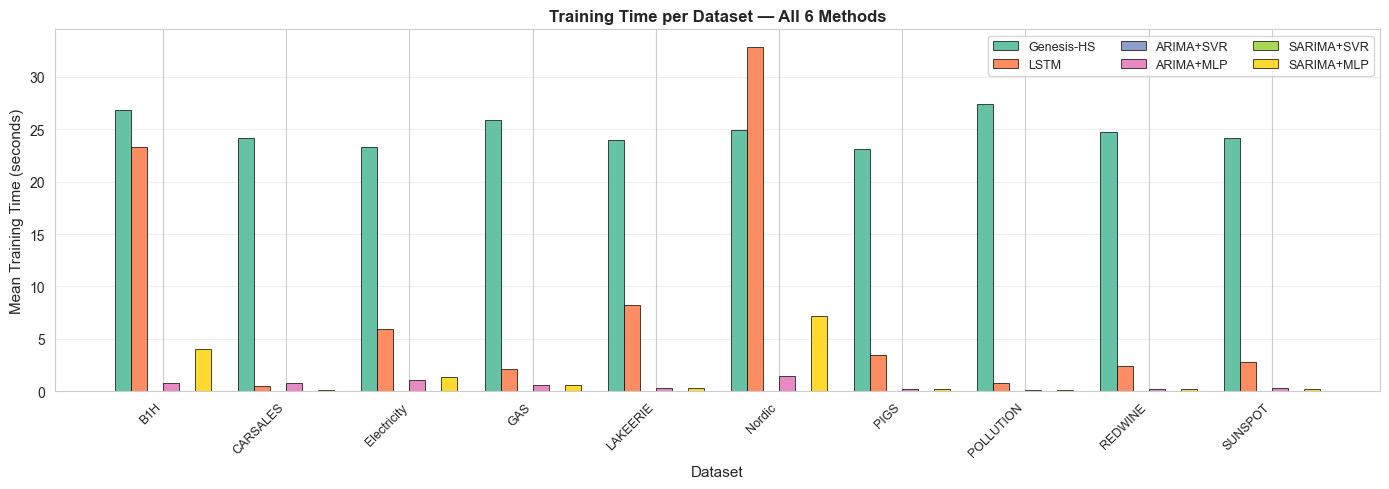

In [21]:
print("COMPUTATIONAL COST — ALL 6 METHODS")
print("=" * 70)
print(f"{'Method':15s} | {'Mean (s)':>10} | {'Median (s)':>10} | {'Std':>8} | {'Min':>7} | {'Max':>7}")
print("-" * 70)
for m in METHOD_ORDER:
    t = perf_matrix_time[m]
    print(f"{m:15s} | {t.mean():10.3f} | {t.median():10.3f} | {t.std():8.3f} | {t.min():7.3f} | {t.max():7.3f}")

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(datasets))
width = 0.13
palette = sns.color_palette("Set2", n_colors=6)
for i, (m, agg) in enumerate(all_agg.items()):
    vals   = [agg.loc[d, 'total_time'] for d in datasets]
    offset = (i - (len(METHOD_ORDER) - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=m,
           color=palette[i], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Dataset', fontsize=11)
ax.set_ylabel('Mean Training Time (seconds)', fontsize=11)
ax.set_title('Training Time per Dataset — All 6 Methods', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=9, ncol=3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Statistical Conclusions and Summary Report

In [22]:
# ── Final summary report ─────────────────────────────────────────────────────
mean_mse_all = {m: round(perf_matrix_mse[m].mean(), 4) for m in METHOD_ORDER}
ge_wins_vs   = {m: int((perf_matrix_mse['Genesis-HS'] < perf_matrix_mse[m]).sum())
                for m in METHOD_ORDER if m != 'Genesis-HS'}

best_method = mean_ranks.idxmin()

print("=" * 80)
print("COMPREHENSIVE STATISTICAL ANALYSIS REPORT")
print("Genesis-HS vs LSTM + 4 Hybrid Methods  (10 datasets, 15 runs each)")
print("Primary metric: MSE (lower is better)")
print("=" * 80)

print("\n1. FRIEDMAN TEST (omnibus)")
print(f"   Chi² = {f_stat:.4f},  p = {f_pval:.6f}")
print(f"   {'SIGNIFICANT' if f_pval < 0.05 else 'NOT SIGNIFICANT'} at α = 0.05")

print("\n2. MEAN RANKS  (Demšar 2006,  lower = better)")
for m, r in mean_ranks.items():
    print(f"   {m:15s}: {r:.4f}{'  ← top-ranked' if m == best_method else ''}")

print(f"\n3. NEMENYI POST-HOC  (CD = {cd_value:.4f} at α = 0.05)")
for m in [x for x in METHOD_ORDER if x != 'Genesis-HS']:
    p   = nemenyi_p.loc['Genesis-HS', m]
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"   Genesis-HS  vs  {m:15s} : p = {p:.4f}  ({sig})")

print("\n4. SUPPLEMENTARY WILCOXON  (Genesis-HS vs LSTM, MSE)")
print(f"   W = {w_stat:.4f},  p = {w_pval:.6f}  "
      f"({'Significant' if w_pval < 0.05 else 'Not significant'})")
print(f"   Cohen's d = {cohens_d:.4f} ({effect} effect size)")

print("\n5. ABSOLUTE PERFORMANCE (MSE)")
print(f"   {'Method':15s} | {'Mean MSE':>9}")
print(f"   {'-'*28}")
for m in METHOD_ORDER:
    print(f"   {m:15s} | {mean_mse_all[m]:9.4f}")

print("\n6. GENESIS-HS WIN COUNT vs EACH COMPETITOR  (Test MSE)")
for m, w in ge_wins_vs.items():
    print(f"   Genesis-HS vs {m:15s}: {w}/{len(datasets)} datasets ({w/len(datasets)*100:.0f}%)")

print("\n7. COMPUTATIONAL COST  (mean training time)")
for m in METHOD_ORDER:
    print(f"   {m:15s}: {perf_matrix_time[m].mean():.3f}s")

print()
print("=" * 80)
print("REVIEWER RESPONSE SUMMARY")
print("=" * 80)
print(
    "Request 1 -- Quantitative evaluation with statistical metrics:\n"
    f"  Friedman test: chi2={f_stat:.4f}, p={f_pval:.6f}\n"
    f"  {'Significant differences exist.' if f_pval < 0.05 else 'No significant differences.'}\n"
    f"  Mean ranks: {', '.join(f'{m}={r:.2f}' for m, r in mean_ranks.items())}\n"
    "\n"
    "Request 2 -- Nemenyi post-hoc for Genesis-HS vs top methods:\n"
    f"  Genesis-HS vs ARIMA+SVR  : p = {nemenyi_p.loc['Genesis-HS','ARIMA+SVR']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','ARIMA+SVR'] < 0.05 else 'not significant'})\n"
    f"  Genesis-HS vs SARIMA+SVR : p = {nemenyi_p.loc['Genesis-HS','SARIMA+SVR']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','SARIMA+SVR'] < 0.05 else 'not significant'})\n"
    f"  Genesis-HS vs ARIMA+MLP  : p = {nemenyi_p.loc['Genesis-HS','ARIMA+MLP']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','ARIMA+MLP'] < 0.05 else 'not significant'})\n"
    f"  Genesis-HS vs SARIMA+MLP : p = {nemenyi_p.loc['Genesis-HS','SARIMA+MLP']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','SARIMA+MLP'] < 0.05 else 'not significant'})\n"
    f"  Genesis-HS vs LSTM       : p = {nemenyi_p.loc['Genesis-HS','LSTM']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','LSTM'] < 0.05 else 'not significant'})"
)

summary_txt = f"""
STATISTICAL ANALYSIS SUMMARY: Genesis-HS vs 5 Methods (Primary metric: MSE)
================================================================================
Methods compared : {len(METHOD_ORDER)}
Datasets analyzed: {len(datasets)}
Runs per config  : 15

FRIEDMAN TEST:
  Chi² = {f_stat:.4f},  p = {f_pval:.6f}
  Significant: {'Yes' if f_pval < 0.05 else 'No'}

MEAN RANKS:
{chr(10).join(f'  {m}: {r:.4f}' for m,r in mean_ranks.items())}

NEMENYI POST-HOC (Genesis-HS vs each):
{chr(10).join(f'  vs {m}: p={nemenyi_p.loc["Genesis-HS",m]:.4f}' for m in METHOD_ORDER if m!='Genesis-HS')}

WILCOXON (GE vs LSTM, supplementary):
  W={w_stat:.4f}, p={w_pval:.6f}, Cohen_d={cohens_d:.4f} ({effect})
"""
with open('results/statistical_analysis_summary.txt', 'w') as fh:
    fh.write(summary_txt)
print("Saved → results/statistical_analysis_summary.txt")

COMPREHENSIVE STATISTICAL ANALYSIS REPORT
Genesis-HS vs LSTM + 4 Hybrid Methods  (10 datasets, 15 runs each)
Primary metric: MSE (lower is better)

1. FRIEDMAN TEST (omnibus)
   Chi² = 18.9080,  p = 0.001999
   SIGNIFICANT at α = 0.05

2. MEAN RANKS  (Demšar 2006,  lower = better)
   SARIMA+MLP     : 2.2000  ← top-ranked
   ARIMA+MLP      : 2.5000
   Genesis-HS     : 2.7000
   ARIMA+SVR      : 4.4000
   SARIMA+SVR     : 4.5000
   LSTM           : 4.7000

3. NEMENYI POST-HOC  (CD = 2.3845 at α = 0.05)
   Genesis-HS  vs  LSTM            : p = 0.1594  (not significant)
   Genesis-HS  vs  ARIMA+SVR       : p = 0.3241  (not significant)
   Genesis-HS  vs  ARIMA+MLP       : p = 0.9999  (not significant)
   Genesis-HS  vs  SARIMA+SVR      : p = 0.2610  (not significant)
   Genesis-HS  vs  SARIMA+MLP      : p = 0.9912  (not significant)

4. SUPPLEMENTARY WILCOXON  (Genesis-HS vs LSTM, MSE)
   W = 7.0000,  p = 0.037109  (Significant)
   Cohen's d = 0.6963 (medium effect size)

5. ABSOLUTE PERFO